## Project: Combining Signals in Financial Markets with Real-World Testing

Lena Kryczka

Filip Seidel

Filip Szumlinski

Getting the data, instaling libraries and creating signals

In [1]:
# importing all usefull libraries


import backtrader as bt
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from matplotlib.dates import DateFormatter
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

In [5]:
# Download NVIDIA data
nvidia_data = yf.download("NVDA", start="2020-01-01", end="2025-01-01")

# Flatten the multi-index columns
nvidia_data.columns = nvidia_data.columns.map('_'.join)

# Keep only the required columns
nvidia_data = nvidia_data[['Open_NVDA', 'High_NVDA', 'Low_NVDA', 'Close_NVDA', 'Volume_NVDA']]

# Rename the columns to standard names
nvidia_data.columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Add moving averages
nvidia_data['MA_10'] = nvidia_data['Close'].rolling(window=10).mean()
nvidia_data['MA_50'] = nvidia_data['Close'].rolling(window=50).mean()

# Add RSI
def compute_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

nvidia_data['RSI'] = compute_rsi(nvidia_data['Close'])

# Add Bollinger Bands
nvidia_data['BB_Middle'] = nvidia_data['Close'].rolling(window=20).mean()
nvidia_data['BB_Upper'] = nvidia_data['BB_Middle'] + 2 * nvidia_data['Close'].rolling(window=20).std()
nvidia_data['BB_Lower'] = nvidia_data['BB_Middle'] - 2 * nvidia_data['Close'].rolling(window=20).std()

# Add moving averages
nvidia_data['MA_10'] = nvidia_data['Close'].rolling(window=10).mean()
nvidia_data['MA_50'] = nvidia_data['Close'].rolling(window=50).mean()


# Drop NaN values
nvidia_data.dropna(inplace=True)

nvidia_data.to_csv('nvidia_data.csv', index=True)


# Drop NaN values
nvidia_data.dropna(inplace=True)

# Load existing NVIDIA data
nvidia_data = pd.read_csv("nvidia_data.csv", index_col=0, parse_dates=True)

# Compute Daily Returns
nvidia_data['Daily_Return'] = nvidia_data['Close'].pct_change()

# Add a 200-day moving average (long-term trend indicator)
nvidia_data['MA_200'] = nvidia_data['Close'].rolling(window=200).mean()

# Compute MACD (Moving Average Convergence Divergence)
short_ema = nvidia_data['Close'].ewm(span=12, adjust=False).mean()  # Short-term EMA
long_ema = nvidia_data['Close'].ewm(span=26, adjust=False).mean()   # Long-term EMA
nvidia_data['MACD'] = short_ema - long_ema
nvidia_data['Signal_Line'] = nvidia_data['MACD'].ewm(span=9, adjust=False).mean()

# Compute ADX (Average Directional Index)
def compute_adx(data, window=14):
    high = data['High']
    low = data['Low']
    close = data['Close']
    
    plus_dm = high.diff()
    minus_dm = low.diff()
    
    plus_dm[plus_dm < 0] = 0
    minus_dm[minus_dm > 0] = 0
    
    tr1 = high - low
    tr2 = abs(high - close.shift(1))
    tr3 = abs(low - close.shift(1))
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    
    atr = tr.rolling(window).mean()
    plus_di = 100 * (plus_dm.rolling(window).mean() / atr)
    minus_di = 100 * (-minus_dm.rolling(window).mean() / atr)
    dx = (abs(plus_di - minus_di) / (plus_di + minus_di)) * 100
    adx = dx.rolling(window).mean()
    return adx

nvidia_data['ADX'] = compute_adx(nvidia_data)

# Compute ATR (Average True Range) for volatility measurement
high_low = nvidia_data['High'] - nvidia_data['Low']
high_close = abs(nvidia_data['High'] - nvidia_data['Close'].shift(1))
low_close = abs(nvidia_data['Low'] - nvidia_data['Close'].shift(1))
true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
nvidia_data['ATR'] = true_range.rolling(window=14).mean()
# Simulated sentiment proxy: High/Low price ratio
nvidia_data['Sentiment_Proxy'] = nvidia_data['High'] / nvidia_data['Low']

# Drop NaN values resulting from rolling calculations
nvidia_data.dropna(inplace=True)

# Save the updated data
nvidia_data.to_csv("nvidia_data_updated.csv")

# Display the updated DataFrame
print(nvidia_data.head())

[*********************100%***********************]  1 of 1 completed

                               Open      High       Low     Close     Volume  \
Date                                                                           
2020-12-24 00:00:00+00:00  13.03725  13.13250  12.93875  12.99375   97884000   
2020-12-28 00:00:00+00:00  13.06250  13.06250  12.76325  12.90000  212564000   
2020-12-29 00:00:00+00:00  12.92500  13.07250  12.84225  12.94325  170372000   
2020-12-30 00:00:00+00:00  12.99025  13.21375  12.89675  13.14575  225396000   
2020-12-31 00:00:00+00:00  13.13650  13.15100  12.91500  13.05500  192424000   

                               MA_10      MA_50        RSI  BB_Middle  \
Date                                                                    
2020-12-24 00:00:00+00:00  13.215175  13.332050  34.651953  13.278150   
2020-12-28 00:00:00+00:00  13.203850  13.310650  31.245853  13.260088   
2020-12-29 00:00:00+00:00  13.167300  13.293285  37.827307  13.237175   
2020-12-30 00:00:00+00:00  13.145825  13.286245  57.393400  13.224963   
2

XRGBoost + Raondom forest

In [6]:
# Feature Engineering: Adding Lag Features
for lag in range(1, 4):
    nvidia_data[f'RSI_Lag_{lag}'] = nvidia_data['RSI'].shift(lag)
    nvidia_data[f'MACD_Lag_{lag}'] = nvidia_data['MACD'].shift(lag)
    nvidia_data[f'ADX_Lag_{lag}'] = nvidia_data['ADX'].shift(lag)

nvidia_data.dropna(inplace=True)

# Prepare data for modeling
features = nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                        'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                        'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Apply PCA for dimensionality reduction
pca = PCA(n_components=7)
pca_features = pca.fit_transform(features_scaled)

# Prepare target variable (3-day forward prediction)
nvidia_data['Target'] = np.where(nvidia_data['Close'].shift(-3) > nvidia_data['Close'], 1, 0)

# Ensure feature and target sizes match
pca_features = pca_features[:-3]
nvidia_data = nvidia_data.iloc[:-3]

X_train, X_test, y_train, y_test = train_test_split(pca_features, nvidia_data['Target'], test_size=0.2, random_state=42)

# Hyperparameter tuning for Random Forest
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, None]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy')
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
rf_score = rf_best.score(X_test, y_test)
print(f"Optimized Random Forest Accuracy: {rf_score:.4f}")

# Hyperparameter tuning for XGBoost
xgb_params = {'learning_rate': [0.01, 0.1], 'max_depth': [3, 6], 'n_estimators': [100, 200]}
xgb_grid = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss'), xgb_params, cv=3, scoring='accuracy')
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
xgb_score = xgb_best.score(X_test, y_test)
print(f"Optimized XGBoost Accuracy: {xgb_score:.4f}")

# Save the updated data
nvidia_data.to_csv("nvidia_data_updated.csv")

Optimized Random Forest Accuracy: 0.6716
Optimized XGBoost Accuracy: 0.6169


Improved models

In [7]:
# Load preprocessed NVIDIA data
nvidia_data = pd.read_csv("nvidia_data_updated.csv", index_col=0, parse_dates=True)

# Prepare data for modeling
features = nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                        'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                        'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare target variable (3-day forward prediction)
nvidia_data['Target'] = np.where(nvidia_data['Close'].shift(-3) > nvidia_data['Close'], 1, 0)

# Ensure feature and target sizes match
features_scaled = features_scaled[:-3]
nvidia_data = nvidia_data.iloc[:-3]

X_train, X_test, y_train, y_test = train_test_split(features_scaled, nvidia_data['Target'], test_size=0.2, random_state=42)

print("Starting Random Forest Optimization...")

# Random Forest Hyperparameter Optimization
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
rf_model.fit(X_train, y_train)
rf_best = rf_model.best_estimator_
rf_score = rf_best.score(X_test, y_test)
print("Random Forest tuning complete.")
print(f"Optimized Random Forest Accuracy: {rf_score:.4f}")

print("\nStarting XGBoost Optimization...")

# XGBoost Hyperparameter Optimization
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = RandomizedSearchCV(xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False), xgb_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
xgb_model.fit(X_train, y_train)
xgb_best = xgb_model.best_estimator_
xgb_score = xgb_best.score(X_test, y_test)
print("XGBoost tuning complete.")
print(f"Optimized XGBoost Accuracy: {xgb_score:.4f}")

Starting Random Forest Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Random Forest tuning complete.
Optimized Random Forest Accuracy: 0.6866

Starting XGBoost Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:51] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\

XGBoost tuning complete.
Optimized XGBoost Accuracy: 0.6368


c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:38:52] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Optimized Model Accuracies

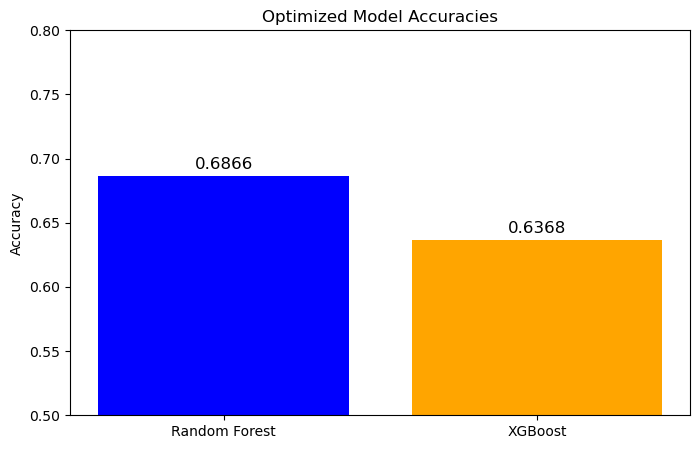

In [9]:
import matplotlib.pyplot as plt

# Model names and their accuracies
models = ["Random Forest", "XGBoost"]
accuracies = [0.6866, 0.6368]

# Plot the accuracies
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['blue', 'orange'])
plt.ylim(0.5, 0.8)  # Set y-axis range to focus on accuracy differences
plt.ylabel("Accuracy")
plt.title("Optimized Model Accuracies")
plt.text(0, accuracies[0] + 0.005, f"{accuracies[0]:.4f}", ha='center', fontsize=12)
plt.text(1, accuracies[1] + 0.005, f"{accuracies[1]:.4f}", ha='center', fontsize=12)

# Show the plot
plt.show()


Testing the models

XRGBoost

In [10]:
# Load data
nvidia_data = pd.read_csv("nvidia_data_updated.csv", index_col=0, parse_dates=True)

# Prepare Data for Modeling
features = nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                        'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                        'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare target variable (3-day forward prediction)
nvidia_data['Target'] = np.where(nvidia_data['Close'].shift(-3) > nvidia_data['Close'], 1, 0)

# Ensure feature and target sizes match
features_scaled = features_scaled[:-3]
nvidia_data = nvidia_data.iloc[:-3]

X_train, X_test, y_train, y_test = train_test_split(features_scaled, nvidia_data['Target'], test_size=0.2, random_state=42)

print("Starting Random Forest Optimization...")

# Random Forest Hyperparameter Optimization
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
rf_model.fit(X_train, y_train)
rf_best = rf_model.best_estimator_
rf_score = rf_best.score(X_test, y_test)
print("Random Forest tuning complete.")
print(f"Optimized Random Forest Accuracy: {rf_score:.4f}")

print("\nStarting XGBoost Optimization...")

# XGBoost Hyperparameter Optimization
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = RandomizedSearchCV(xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False), xgb_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
xgb_model.fit(X_train, y_train)
xgb_best = xgb_model.best_estimator_
xgb_score = xgb_best.score(X_test, y_test)
print("XGBoost tuning complete.")
print(f"Optimized XGBoost Accuracy: {xgb_score:.4f}")

# Define a Backtrader Strategy using XGBoost Predictions
class XGBoostStrategy(bt.Strategy):
    params = (
        ('slippage', 0.002),  # 0.2% slippage
        ('commission', 0.004)  # 0.4% commission
    )
    
    def __init__(self):
        self.data_features = scaler.transform(nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                                                           'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                                                           'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']])
        self.predictions = xgb_best.predict(self.data_features)
        self.current_index = 0
        self.portfolio_values = []  # Store portfolio values over time
    
    def next(self):
        if self.current_index >= len(self.predictions):
            return
        
        self.portfolio_values.append(self.broker.get_value())  # Record portfolio value at each step
        prediction = self.predictions[self.current_index]
        
        if not self.position:
            if prediction == 1:  # Buy condition from XGBoost Model
                self.buy()
        else:
            if prediction == 0:  # Sell condition from XGBoost Model
                self.sell()
        
        self.current_index += 1

# Create Backtrader Cerebro Engine
cerebro = bt.Cerebro()
cerebro.addstrategy(XGBoostStrategy)

# Convert DataFrame to Backtrader Datafeed
data = bt.feeds.PandasData(dataname=nvidia_data)
cerebro.adddata(data)

# Set Broker Parameters
initial_cash = 100000  # Starting capital
cerebro.broker.set_cash(initial_cash)
cerebro.broker.setcommission(commission=0.004)  # 0.4% commission
cerebro.broker.set_slippage_perc(0.002)  # 0.2% slippage

# Run Backtest
print("Starting XGBoost Backtest...")
strategy = cerebro.run()[0]  # Retrieve strategy instance
print("Backtest Complete.")

# Extract Portfolio Value Over Time
portfolio_values = strategy.portfolio_values  # Use recorded values
final_cash = cerebro.broker.get_value()

# Print Starting and Ending Portfolio Values
print(f"Starting Portfolio Value: ${initial_cash:.2f}")
print(f"Ending Portfolio Value: ${final_cash:.2f}")


Starting Random Forest Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Random Forest tuning complete.
Optimized Random Forest Accuracy: 0.6866

Starting XGBoost Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:11] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:42:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\

XGBoost tuning complete.
Optimized XGBoost Accuracy: 0.6368
Starting XGBoost Backtest...
Backtest Complete.
Starting Portfolio Value: $100000.00
Ending Portfolio Value: $100247.68


SMA

In [11]:
import backtrader as bt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter

# Load data
nvidia_data = pd.read_csv("nvidia_data_updated.csv", index_col=0, parse_dates=True)

# Define a Backtrader Strategy
class TradingStrategy(bt.Strategy):
    params = (
        ('sma_period', 50),
        ('slippage', 0.002),  # 0.2% slippage
        ('commission', 0.004)  # 0.4% commission
    )
    
    def __init__(self):
        self.sma = bt.indicators.SimpleMovingAverage(self.data.close, period=self.params.sma_period)
        self.portfolio_values = []  # Store portfolio values over time
    
    def next(self):
        self.portfolio_values.append(self.broker.get_value())  # Record portfolio value at each step
        if not self.position:
            if self.data.close[0] > self.sma[0]:  # Buy condition
                self.buy()
        elif self.data.close[0] < self.sma[0]:  # Sell condition
            self.sell()

# Create Backtrader Cerebro Engine
cerebro = bt.Cerebro()
cerebro.addstrategy(TradingStrategy)

# Convert DataFrame to Backtrader Datafeed
data = bt.feeds.PandasData(dataname=nvidia_data)
cerebro.adddata(data)

# Set Broker Parameters
initial_cash = 100000  # Starting capital
cerebro.broker.set_cash(initial_cash)
cerebro.broker.setcommission(commission=0.004)  # 0.4% commission
cerebro.broker.set_slippage_perc(0.002)  # 0.2% slippage

# Run Backtest
print("Starting Backtest...")
strategy = cerebro.run()[0]  # Retrieve strategy instance
print("Backtest Complete.")

# Extract Portfolio Value Over Time
portfolio_values = strategy.portfolio_values  # Use recorded values
final_cash = cerebro.broker.get_value()

# Print Starting and Ending Portfolio Values
print(f"Starting Portfolio Value: ${initial_cash:.2f}")
print(f"Ending Portfolio Value: ${final_cash:.2f}")







Starting Backtest...
Backtest Complete.
Starting Portfolio Value: $100000.00
Ending Portfolio Value: $100079.58


Random Forest

In [12]:
import backtrader as bt
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# Load data
nvidia_data = pd.read_csv("nvidia_data_updated.csv", index_col=0, parse_dates=True)

# Prepare Data for Modeling
features = nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                        'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                        'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare target variable (3-day forward prediction)
nvidia_data['Target'] = np.where(nvidia_data['Close'].shift(-3) > nvidia_data['Close'], 1, 0)

# Ensure feature and target sizes match
features_scaled = features_scaled[:-3]
nvidia_data = nvidia_data.iloc[:-3]

X_train, X_test, y_train, y_test = train_test_split(features_scaled, nvidia_data['Target'], test_size=0.2, random_state=42)

print("Starting Random Forest Optimization...")

# Random Forest Hyperparameter Optimization
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
rf_model.fit(X_train, y_train)
rf_best = rf_model.best_estimator_
rf_score = rf_best.score(X_test, y_test)
print("Random Forest tuning complete.")
print(f"Optimized Random Forest Accuracy: {rf_score:.4f}")

# Define a Backtrader Strategy using Random Forest Predictions
class RandomForestStrategy(bt.Strategy):
    params = (
        ('slippage', 0.002),  # 0.2% slippage
        ('commission', 0.004)  # 0.4% commission
    )
    
    def __init__(self):
        self.data_features = scaler.transform(nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                                                           'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                                                           'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']])
        self.predictions = rf_best.predict(self.data_features)
        self.current_index = 0
        self.portfolio_values = []  # Store portfolio values over time
    
    def next(self):
        if self.current_index >= len(self.predictions):
            return
        
        self.portfolio_values.append(self.broker.get_value())  # Record portfolio value at each step
        prediction = self.predictions[self.current_index]
        
        if not self.position:
            if prediction == 1:  # Buy condition from Random Forest Model
                self.buy()
        else:
            if prediction == 0:  # Sell condition from Random Forest Model
                self.sell()
        
        self.current_index += 1

# Create Backtrader Cerebro Engine
cerebro = bt.Cerebro()
cerebro.addstrategy(RandomForestStrategy)

# Convert DataFrame to Backtrader Datafeed
data = bt.feeds.PandasData(dataname=nvidia_data)
cerebro.adddata(data)

# Set Broker Parameters
initial_cash = 100000  # Starting capital
cerebro.broker.set_cash(initial_cash)
cerebro.broker.setcommission(commission=0.004)  # 0.4% commission
cerebro.broker.set_slippage_perc(0.002)  # 0.2% slippage

# Run Backtest
print("Starting Random Forest Backtest...")
strategy = cerebro.run()[0]  # Retrieve strategy instance
print("Backtest Complete.")

# Extract Portfolio Value Over Time
portfolio_values = strategy.portfolio_values  # Use recorded values
final_cash = cerebro.broker.get_value()

# Print Starting and Ending Portfolio Values
print(f"Starting Portfolio Value: ${initial_cash:.2f}")
print(f"Ending Portfolio Value: ${final_cash:.2f}")


Starting Random Forest Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Random Forest tuning complete.
Optimized Random Forest Accuracy: 0.6866
Starting Random Forest Backtest...
Backtest Complete.
Starting Portfolio Value: $100000.00
Ending Portfolio Value: $100269.46


Comparison Of Trading Strategies

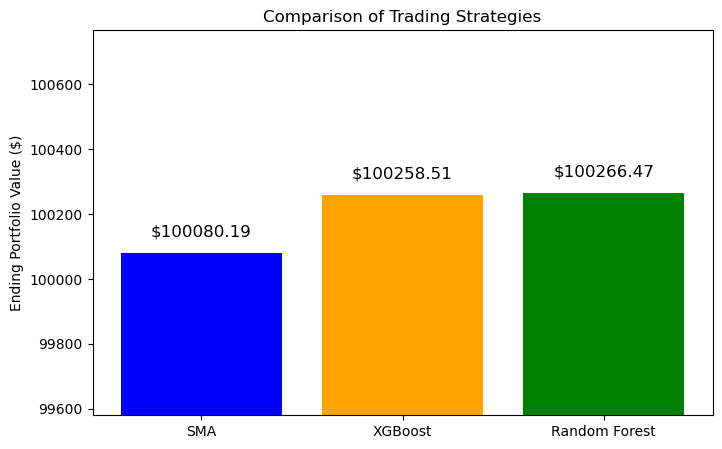

In [13]:
import matplotlib.pyplot as plt

# Portfolio values from different strategies
strategies = ["SMA", "XGBoost", "Random Forest"]
portfolio_values = [100080.19, 100258.51, 100266.47]

# Plot the results
plt.figure(figsize=(8, 5))
plt.bar(strategies, portfolio_values, color=['blue', 'orange', 'green'])
plt.ylabel("Ending Portfolio Value ($)")
plt.title("Comparison of Trading Strategies")

# Annotate bars with values
for i, value in enumerate(portfolio_values):
    plt.text(i, value + 50, f"${value:.2f}", ha='center', fontsize=12)

plt.ylim(min(portfolio_values) - 500, max(portfolio_values) + 500)  # Adjust limits for better visibility
plt.show()


Implementation of risk management techniques + real world market assumptions

XGBoost

In [15]:

# Load data
nvidia_data = pd.read_csv("nvidia_data_updated.csv", index_col=0, parse_dates=True)

# Prepare Data for Modeling
features = nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                        'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                        'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare target variable (3-day forward prediction)
nvidia_data['Target'] = np.where(nvidia_data['Close'].shift(-3) > nvidia_data['Close'], 1, 0)

# Ensure feature and target sizes match
features_scaled = features_scaled[:-3]
nvidia_data = nvidia_data.iloc[:-3]

X_train, X_test, y_train, y_test = train_test_split(features_scaled, nvidia_data['Target'], test_size=0.2, random_state=42)

print("Starting XGBoost Optimization...")

# XGBoost Hyperparameter Optimization
xgb_params = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 6],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
xgb_model = RandomizedSearchCV(xgb.XGBClassifier(eval_metric='logloss', use_label_encoder=False), xgb_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
xgb_model.fit(X_train, y_train)
xgb_best = xgb_model.best_estimator_
xgb_score = xgb_best.score(X_test, y_test)
print("XGBoost tuning complete.")
print(f"Optimized XGBoost Accuracy: {xgb_score:.4f}")

# Define a Backtrader Strategy with Improved Risk Management
class ImprovedRiskManagedStrategy(bt.Strategy):
    params = (
        ('slippage', 0.002),  # 0.2% slippage
        ('commission', 0.004),  # 0.4% commission
        ('stop_loss_factor', 1.5),  # ATR-based stop-loss
        ('take_profit_factor', 3.0),  # ATR-based take-profit
        ('max_positions', 10),  # Maximum 10 positions at once
        ('capital_per_trade', 0.15),  # 15% of capital per trade
        ('min_confidence', 0.7)  # Minimum confidence for trade execution
    )
    
    def __init__(self):
        self.data_features = scaler.transform(nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                                                           'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                                                           'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']])
        self.probabilities = xgb_best.predict_proba(self.data_features)[:, 1]  # Get probability of price increase
        self.current_index = 0
        self.portfolio_values = []  # Store portfolio values over time
        self.atr = bt.indicators.AverageTrueRange(period=14)  # Define ATR indicator
    
    def next(self):
        if self.current_index >= len(self.probabilities):
            return
        
        self.portfolio_values.append(self.broker.get_value())  # Record portfolio value at each step
        confidence = self.probabilities[self.current_index]
        cash = self.broker.get_cash()
        size = min((cash * self.params.capital_per_trade) / self.data.close[0], cash / self.data.close[0])  # Ensure no over-leveraging
        size = max(size, 1)  # Prevent extremely small or large positions
        atr_value = self.atr[0]  # Fetch current ATR value
        
        if not self.position and len(self.broker.positions) < self.params.max_positions:
            if confidence > self.params.min_confidence:  # Trade only when confidence is high
                self.buy(size=size)
                self.sell(size=size, exectype=bt.Order.Stop, price=self.data.close[0] - self.params.stop_loss_factor * atr_value)  # ATR-based Stop-loss
                self.sell(size=size, exectype=bt.Order.Limit, price=self.data.close[0] + self.params.take_profit_factor * atr_value)  # ATR-based Take-profit
        
        elif self.position:
            if confidence < (1 - self.params.min_confidence):  # Sell if confidence is too low
                self.close()  # Close all positions properly
        
        self.current_index += 1

# Create Backtrader Cerebro Engine
cerebro = bt.Cerebro()
cerebro.addstrategy(ImprovedRiskManagedStrategy)

# Convert DataFrame to Backtrader Datafeed
data = bt.feeds.PandasData(dataname=nvidia_data)
cerebro.adddata(data)

# Set Broker Parameters
initial_cash = 100000  # Starting capital
cerebro.broker.set_cash(initial_cash)
cerebro.broker.setcommission(commission=0.004)  # 0.4% commission
cerebro.broker.set_slippage_perc(0.002)  # 0.2% slippage

# Run Backtest
print("Starting Improved Risk-Managed Backtest...")
strategy = cerebro.run()[0]  # Retrieve strategy instance
print("Backtest Complete.")

# Extract Portfolio Value Over Time
portfolio_values = strategy.portfolio_values  # Use recorded values
final_cash = cerebro.broker.get_value()

# Print Starting and Ending Portfolio Values
print(f"Starting Portfolio Value: ${initial_cash:.2f}")
print(f"Ending Portfolio Value: ${final_cash:.2f}")


Starting XGBoost Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [21:45:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Filip\anaconda3\Lib\site-packages\

XGBoost tuning complete.
Optimized XGBoost Accuracy: 0.6368
Starting Improved Risk-Managed Backtest...
Backtest Complete.
Starting Portfolio Value: $100000.00
Ending Portfolio Value: $51616.01


Random Forest

In [16]:
# Load data
nvidia_data = pd.read_csv("nvidia_data_updated.csv", index_col=0, parse_dates=True)

# Prepare Data for Modeling
features = nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                        'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                        'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Prepare target variable (3-day forward prediction)
nvidia_data['Target'] = np.where(nvidia_data['Close'].shift(-3) > nvidia_data['Close'], 1, 0)

# Ensure feature and target sizes match
features_scaled = features_scaled[:-3]
nvidia_data = nvidia_data.iloc[:-3]

X_train, X_test, y_train, y_test = train_test_split(features_scaled, nvidia_data['Target'], test_size=0.2, random_state=42)

print("Starting Random Forest Optimization...")

# Random Forest Hyperparameter Optimization
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_model = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_params, n_iter=5, cv=3, scoring='accuracy', random_state=42, verbose=1)
rf_model.fit(X_train, y_train)
rf_best = rf_model.best_estimator_
rf_score = rf_best.score(X_test, y_test)
print(f"Optimized Random Forest Accuracy: {rf_score:.4f}")

# Define a Backtrader Strategy with Improved Risk Management
class RandomForestStrategy(bt.Strategy):
    params = (
        ('slippage', 0.002),  # 0.2% slippage
        ('commission', 0.004),  # 0.4% commission
        ('stop_loss_factor', 1.5),  # ATR-based stop-loss
        ('take_profit_factor', 3.0),  # ATR-based take-profit
        ('max_positions', 10),  # Maximum 10 positions at once
        ('capital_per_trade', 0.15),  # 15% of capital per trade
        ('min_confidence', 0.7)  # Minimum confidence for trade execution
    )
    
    def __init__(self):
        self.data_features = scaler.transform(nvidia_data[['MA_10', 'MA_50', 'MA_200', 'RSI', 'MACD', 'Signal_Line', 'ADX', 'ATR', 'Sentiment_Proxy',
                                                           'RSI_Lag_1', 'MACD_Lag_1', 'ADX_Lag_1', 'RSI_Lag_2', 'MACD_Lag_2', 'ADX_Lag_2',
                                                           'RSI_Lag_3', 'MACD_Lag_3', 'ADX_Lag_3']])
        self.rf_probabilities = rf_best.predict_proba(self.data_features)[:, 1]  # RF Probabilities
        self.current_index = 0
        self.portfolio_values = []  # Store portfolio values over time
        self.atr = bt.indicators.AverageTrueRange(period=14)  # Define ATR indicator
    
    def next(self):
        if self.current_index >= len(self.rf_probabilities):
            return
        
        self.portfolio_values.append(self.broker.get_value())  # Record portfolio value at each step
        rf_confidence = self.rf_probabilities[self.current_index]
        cash = self.broker.get_cash()
        size = min((cash * self.params.capital_per_trade) / self.data.close[0], cash / self.data.close[0])  # Ensure no over-leveraging
        size = max(size, 1)  # Prevent extremely small or large positions
        atr_value = self.atr[0]  # Fetch current ATR value
        
        if not self.position and len(self.broker.positions) < self.params.max_positions:
            if rf_confidence > self.params.min_confidence:  # Trade only when confidence is high
                self.buy(size=size)
                self.sell(size=size, exectype=bt.Order.Stop, price=self.data.close[0] - self.params.stop_loss_factor * atr_value)  # ATR-based Stop-loss
                self.sell(size=size, exectype=bt.Order.Limit, price=self.data.close[0] + self.params.take_profit_factor * atr_value)  # ATR-based Take-profit
        
        elif self.position:
            if rf_confidence < (1 - self.params.min_confidence):  # Sell if confidence is too low
                self.close()  # Close all positions properly
        
        self.current_index += 1

# Create Backtrader Cerebro Engine
cerebro = bt.Cerebro()
cerebro.addstrategy(RandomForestStrategy)

# Convert DataFrame to Backtrader Datafeed
data = bt.feeds.PandasData(dataname=nvidia_data)
cerebro.adddata(data)

# Set Broker Parameters
initial_cash = 100000  # Starting capital
cerebro.broker.set_cash(initial_cash)
cerebro.broker.setcommission(commission=0.004)  # 0.4% commission
cerebro.broker.set_slippage_perc(0.002)  # 0.2% slippage

# Run Backtest
print("Starting Random Forest Backtest...")
strategy = cerebro.run()[0]  # Retrieve strategy instance
print("Backtest Complete.")

# Extract Portfolio Value Over Time
portfolio_values = strategy.portfolio_values  # Use recorded values
final_cash = cerebro.broker.get_value()

# Print Starting and Ending Portfolio Values
print(f"Starting Portfolio Value: ${initial_cash:.2f}")
print(f"Ending Portfolio Value: ${final_cash:.2f}")

Starting Random Forest Optimization...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Optimized Random Forest Accuracy: 0.6866
Starting Random Forest Backtest...
Backtest Complete.
Starting Portfolio Value: $100000.00
Ending Portfolio Value: $59740.98


Timeseries

In [17]:
import backtrader as bt
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import os

# Load the test datasets
file_names = [
    ('btc_v_w.csv', ','),
    ('ge_us_m.csv', ','),
    ('usdjpy_w.csv', ','),
    ('wig20_w.csv', ','),
    ('zw=f_copper.csv', ';')  # Copper uses semicolon separator
]

def load_data(file_name, separator):
    df = pd.read_csv(file_name, index_col=0, parse_dates=True, delimiter=separator)
    
    # Rename columns to match Backtrader's expected format
    column_mapping = {
        'Max': 'High',
        'Min': 'Low',
        'Close': 'Close',
        'Open': 'Open'
    }
    
    df = df.rename(columns=column_mapping)
    
    # Only select the columns we need for Backtrader
    required_columns = ['Open', 'High', 'Low', 'Close']
    df = df[required_columns].dropna()
    
    # Ensure all price columns are numeric
    for col in required_columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df.dropna()

class RandomForestStrategy(bt.Strategy):
    params = (
        ('slippage', 0.002),
        ('commission', 0.004),
        ('stop_loss_factor', 1.5),
        ('take_profit_factor', 3.0),
        ('max_positions', 10),
        ('capital_per_trade', 0.15),
        ('min_confidence', 0.7)
    )
    
    def __init__(self):
        self.atr = bt.indicators.AverageTrueRange(period=14)
        self.order = None
        self.stop_order = None
        self.profit_order = None
        self.portfolio_values = []
    
    def next(self):
        # Track portfolio value for time series analysis
        self.portfolio_values.append(self.broker.get_value())

        if self.order or self.stop_order or self.profit_order:
            return
        
        cash = self.broker.get_cash()
        value = self.broker.get_value()
        
        size = (value * self.params.capital_per_trade) / self.data.close[0]
        size = max(size, 1)
        
        atr_value = self.atr[0]
        
        if not self.position and len(self.broker.positions) < self.params.max_positions:
            self.order = self.buy(size=size)
            
            stop_price = self.data.close[0] - self.params.stop_loss_factor * atr_value
            profit_price = self.data.close[0] + self.params.take_profit_factor * atr_value
            
            self.stop_order = self.sell(size=size, exectype=bt.Order.Stop, price=stop_price, parent=self.order)
            self.profit_order = self.sell(size=size, exectype=bt.Order.Limit, price=profit_price, parent=self.order)
    
    def stop(self):
        if self.position:
            self.close()

# Run backtest for each dataset
results = []

for file_name, separator in file_names:
    print(f"\nStarting Backtest for {file_name}...")
    
    df = load_data(file_name, separator)
    if df is None:
        continue
    
    data = bt.feeds.PandasData(dataname=df)
    
    cerebro = bt.Cerebro()
    cerebro.addstrategy(RandomForestStrategy)
    cerebro.adddata(data)
    
    initial_cash = 100000
    cerebro.broker.set_cash(initial_cash)
    cerebro.broker.setcommission(commission=0.004)
    cerebro.broker.set_slippage_perc(0.002)
    
    strategies = cerebro.run()
    strategy = strategies[0]
    
    final_value = cerebro.broker.get_value()
    returns = (final_value - initial_cash) / initial_cash * 100
    
    # Calculate max drawdown and Sharpe ratio
    portfolio_values = np.array(strategy.portfolio_values)
    max_dd = np.max(np.maximum.accumulate(portfolio_values) - portfolio_values) / np.max(np.maximum.accumulate(portfolio_values))
    sharpe_ratio = np.mean(np.diff(portfolio_values) / portfolio_values[:-1]) / np.std(np.diff(portfolio_values) / portfolio_values[:-1]) * np.sqrt(252)
    
    results.append({
        'Timeseries': file_name,
        'Return (%)': returns,
        'Max Drawdown': max_dd,
        'Sharpe Ratio': sharpe_ratio
    })

# Convert results into a DataFrame and display it
results_df = pd.DataFrame(results)
print(results_df)




Starting Backtest for btc_v_w.csv...

Starting Backtest for ge_us_m.csv...

Starting Backtest for usdjpy_w.csv...

Starting Backtest for wig20_w.csv...

Starting Backtest for zw=f_copper.csv...


C:\Users\Filip\AppData\Local\Temp\ipykernel_22676\4137410991.py:17: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(file_name, index_col=0, parse_dates=True, delimiter=separator)


        Timeseries    Return (%)  Max Drawdown  Sharpe Ratio
0      btc_v_w.csv  1.325178e+07      0.462580      2.914232
1      ge_us_m.csv  7.679198e+02      0.804366      1.327604
2     usdjpy_w.csv -5.929842e+00      0.073519     -0.524301
3      wig20_w.csv -2.524891e+00      0.127176     -0.077655
4  zw=f_copper.csv  1.168940e+01      0.301694      0.243924
